In [2]:
import scanpy as sc
import anndata as ad

In [ ]:
hiha = ad.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHA_hgnc.h5ad")

In [14]:
len(hiha.obs['donor_id'].value_counts())

108

In [7]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"


### barplot all HIHA cells 

In [32]:
import pandas as pd

color_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/hiha_palette_final.csv")
real_hex_lookup = dict(zip(color_df["hiha_cell_type_CL"], color_df["hex_color"]))




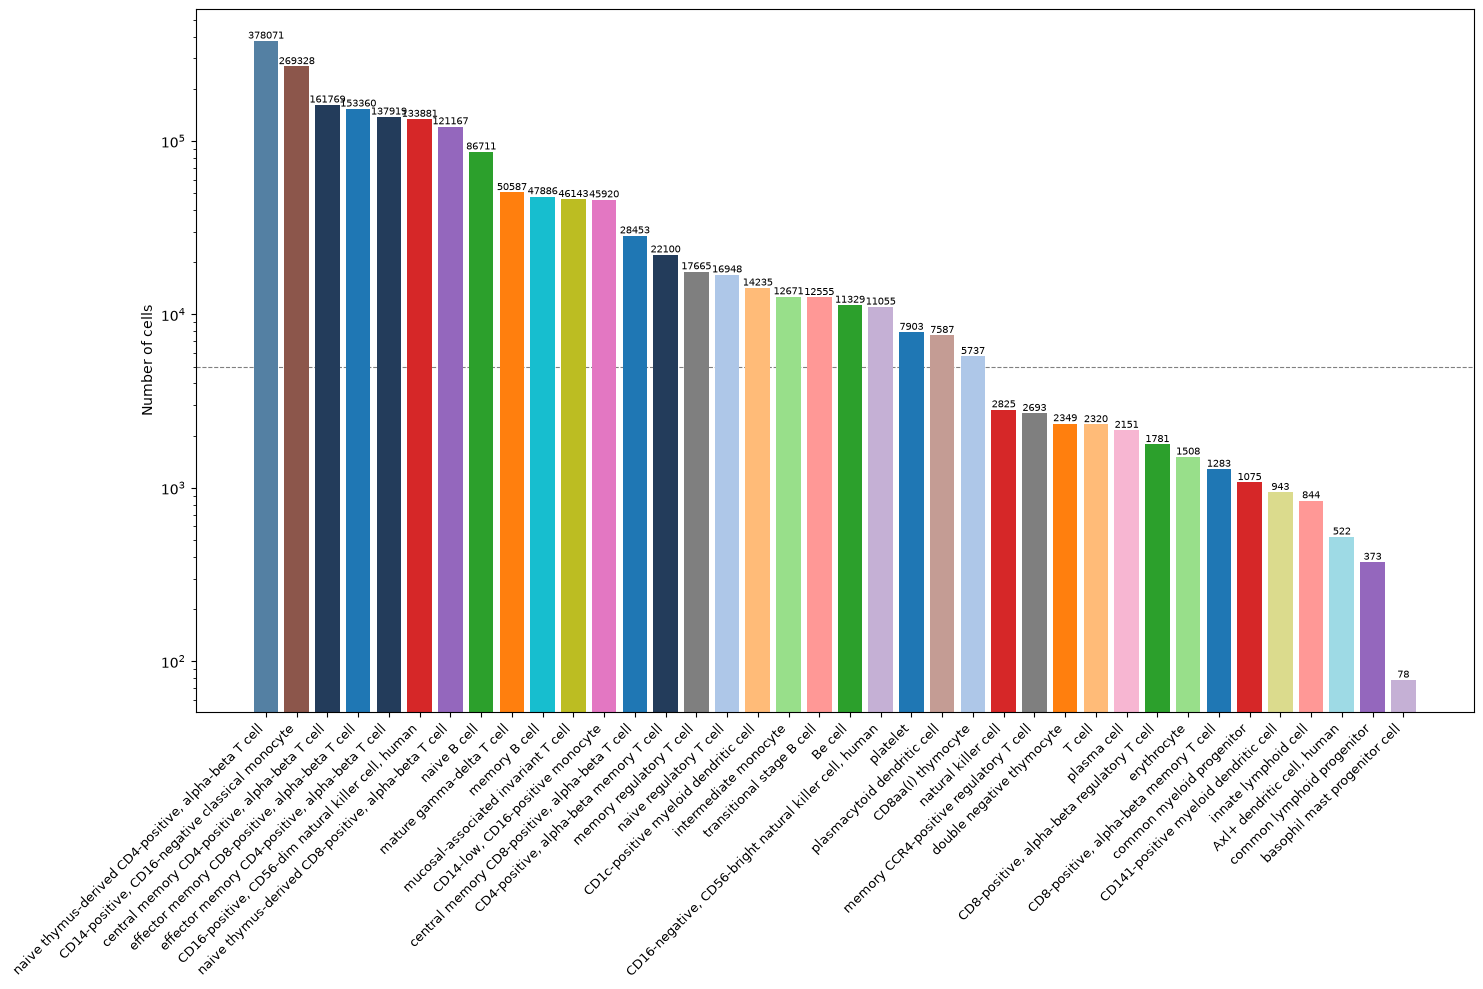

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os

orig_col = "cell_type"
orig_counts = hiha.obs[orig_col].value_counts()
bar_colors = [real_hex_lookup[ct] for ct in orig_counts.index]


fig, ax = plt.subplots(figsize=(15, 10))
ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
bars = ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
ax.axhline(5000, color="grey", linestyle="--", linewidth=0.8, zorder=0)
ax.set_yscale("log")
for bar, val in zip(bars, orig_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(val),
            ha="center", va="bottom", fontsize=7)
ax.set_ylabel("Number of cells", fontsize=10)
ax.set_xlabel("")
ax.set_xticks(range(len(orig_counts)))
ax.set_xticklabels(orig_counts.index, rotation=45, ha="right", fontsize=9)
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR,"09_11_all_barplot_cell_type.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

### TICA annotation barplot

In [3]:
hiha_ds = ad.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin2.h5ad")

In [4]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    # "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    # "Mast cells":                  "#C075A6",
}

current_cats = set(hiha_ds.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
hiha_ds.obs["decoupler_level1_celltype"] = hiha_ds.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))



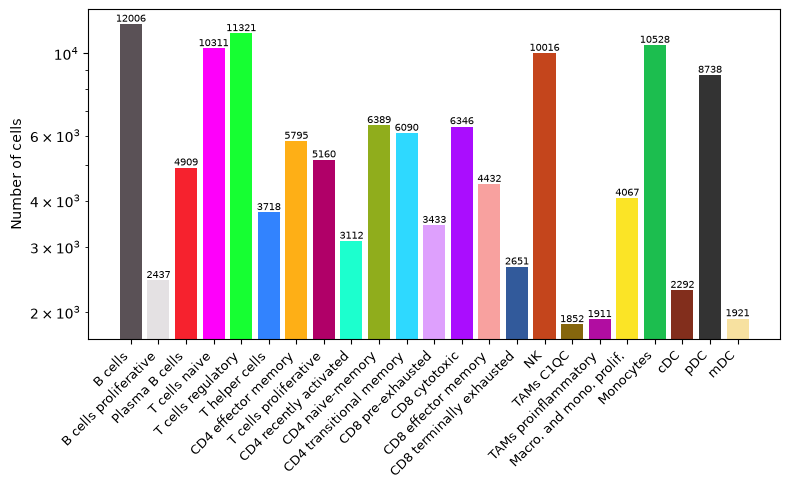

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os

orig_col = "decoupler_level1_celltype"
orig_counts = hiha_ds.obs[orig_col].value_counts(sort=False)

bar_colors = [celltype_palette[ct] for ct in orig_counts.index]


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
bars = ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
ax.set_yscale("log")
for bar, val in zip(bars, orig_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(val),
            ha="center", va="bottom", fontsize=7)
ax.set_ylabel("Number of cells", fontsize=10)
ax.set_xlabel("")
ax.set_xticks(range(len(orig_counts)))
ax.set_xticklabels(orig_counts.index, rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"09_11_barplot_ticalvl1.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

### river plot original cell type vs TICA annotation


In [5]:
hiha_custom_order = [
    "transitional stage B cell",
    "naive B cell",
    "memory B cell",
    "Be cell",
    "plasma cell",
    "T cell",  
    "effector memory CD4-positive, alpha-beta T cell",
    "CD4-positive, alpha-beta memory T cell",
    "central memory CD4-positive, alpha-beta T cell",
    "central memory CD8-positive, alpha-beta T cell",
    "effector memory CD8-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta memory T cell",
    "naive thymus-derived CD4-positive, alpha-beta T cell",
    "naive thymus-derived CD8-positive, alpha-beta T cell",
    "CD8aa(I) thymocyte",
    "double negative thymocyte",
    "common lymphoid progenitor",
    "naive regulatory T cell",
    "memory regulatory T cell",
    "memory CCR4-positive regulatory T cell",
    "CD8-positive, alpha-beta regulatory T cell",
    "mucosal-associated invariant T cell",
    "mature gamma-delta T cell",
    "innate lymphoid cell",
    "CD14-positive, CD16-negative classical monocyte",
    "intermediate monocyte",
    "CD14-low, CD16-positive monocyte",
    "common myeloid progenitor",
    "CD16-negative, CD56-bright natural killer cell, human",
    "CD16-positive, CD56-dim natural killer cell, human",
    "natural killer cell",
    "CD1c-positive myeloid dendritic cell",
    "CD141-positive myeloid dendritic cell",
    "Axl+ dendritic cell, human",
    "plasmacytoid dendritic cell",
    "basophil mast progenitor cell",
    "platelet",
    "erythrocyte",
]

hiha_ds.obs["cell_type"] = hiha_ds.obs["cell_type"].cat.reorder_categories(hiha_custom_order)
source_order = list(hiha_ds.obs["cell_type"].cat.categories)

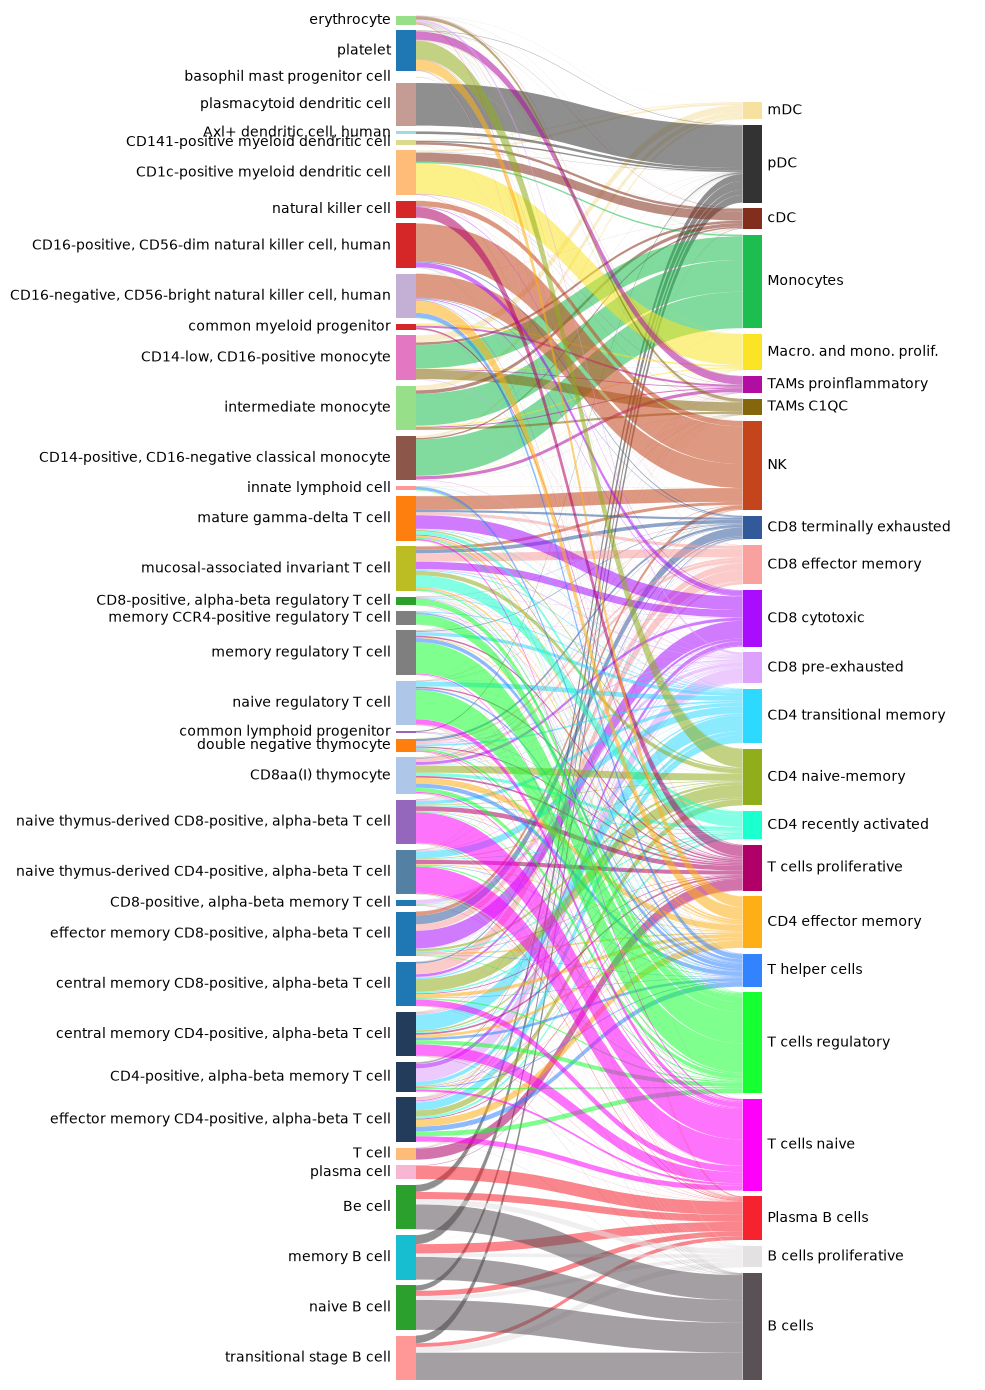

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import pandas as pd
import os


def riverplot(df, source_col, target_col, source_palette, target_palette,
              source_order=None, target_order=None, figsize=(10, 16)):
    flow = df.groupby([source_col, target_col], observed=True).size().reset_index(name="count")
    flow = flow[flow["count"] > 0]

    src_labels = source_order if source_order else list(source_palette.keys())
    tgt_labels = target_order if target_order else list(target_palette.keys())

    src_totals = flow.groupby(source_col, observed=True)["count"].sum().reindex(src_labels).fillna(0)
    tgt_totals = flow.groupby(target_col, observed=True)["count"].sum().reindex(tgt_labels).fillna(0)

    gap = max(src_totals.sum(), tgt_totals.sum()) * 0.005

    src_y_start, y = {}, 0
    for lbl in src_labels:
        src_y_start[lbl] = y
        y += src_totals[lbl] + gap

    tgt_y_start, y = {}, 0
    for lbl in tgt_labels:
        tgt_y_start[lbl] = y
        y += tgt_totals[lbl] + gap

    fig, ax = plt.subplots(figsize=figsize)
    src_cursor = {lbl: src_y_start[lbl] for lbl in src_labels}
    tgt_cursor = {lbl: tgt_y_start[lbl] for lbl in tgt_labels}
    flow_sorted = flow.sort_values(by=[source_col, target_col])

    bar_w = 0.04
    x0, x1, xm = 0.15 + bar_w / 2, 0.85 - bar_w / 2, 0.5

    for _, row in flow_sorted.iterrows():
        s, t, c = row[source_col], row[target_col], row["count"]
        y0_s, y1_s = src_cursor[s], src_cursor[s] + c
        y0_t, y1_t = tgt_cursor[t], tgt_cursor[t] + c
        src_cursor[s], tgt_cursor[t] = y1_s, y1_t

        verts_top = [(x0, y0_s), (xm, y0_s), (xm, y0_t), (x1, y0_t)]
        verts_bot = [(x1, y1_t), (xm, y1_t), (xm, y1_s), (x0, y1_s)]
        path = Path(
            verts_top + verts_bot + [verts_bot[-1]],
            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            + [Path.LINETO] + [Path.CURVE4, Path.CURVE4, Path.CURVE4] + [Path.CLOSEPOLY],
        )
        # Bandfarbe folgt der Zielkategorie (decoupler_level1_celltype)
        color = target_palette.get(t, "#CCCCCC")
        ax.add_patch(mpatches.PathPatch(path, facecolor=color, edgecolor="none", alpha=0.55, lw=0))

    for lbl in src_labels:
        # Original-Farbe je cell_type Kategorie
        color = source_palette.get(lbl, "#CCCCCC")
        ax.add_patch(mpatches.Rectangle((x0 - bar_w, src_y_start[lbl]), bar_w, src_totals[lbl],
                                         facecolor=color, edgecolor="none"))
        ax.text(x0 - bar_w - 0.01, src_y_start[lbl] + src_totals[lbl] / 2, lbl,
                ha="right", va="center", fontsize=10)

    for lbl in tgt_labels:
        color = target_palette.get(lbl, "#CCCCCC")
        ax.add_patch(mpatches.Rectangle((x1, tgt_y_start[lbl]), bar_w, tgt_totals[lbl],
                                         facecolor=color, edgecolor="none"))
        ax.text(x1 + bar_w + 0.01, tgt_y_start[lbl] + tgt_totals[lbl] / 2, lbl,
                ha="left", va="center", fontsize=10)

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(0, max(src_totals.sum(), tgt_totals.sum()) + gap * len(src_labels))
    ax.axis("off")
    return fig, ax


color_df = pd.read_csv(
    "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/hiha_palette_final.csv"
)
source_palette = dict(zip(color_df["hiha_cell_type_CL"], color_df["hex_color"]))

source_col = "cell_type"
target_col = "decoupler_level1_celltype"

source_order = list(hiha_ds.obs[source_col].cat.categories) if hasattr(hiha_ds.obs[source_col], "cat") \
    else sorted(hiha_ds.obs[source_col].unique())
target_order = list(celltype_palette.keys())

fig, ax = riverplot(hiha_ds.obs, source_col, target_col, source_palette, celltype_palette,
                     source_order=source_order, target_order=target_order,
                     figsize=(10, 14))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_11_riverplot_celltype_to_ticalvl1.pdf"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

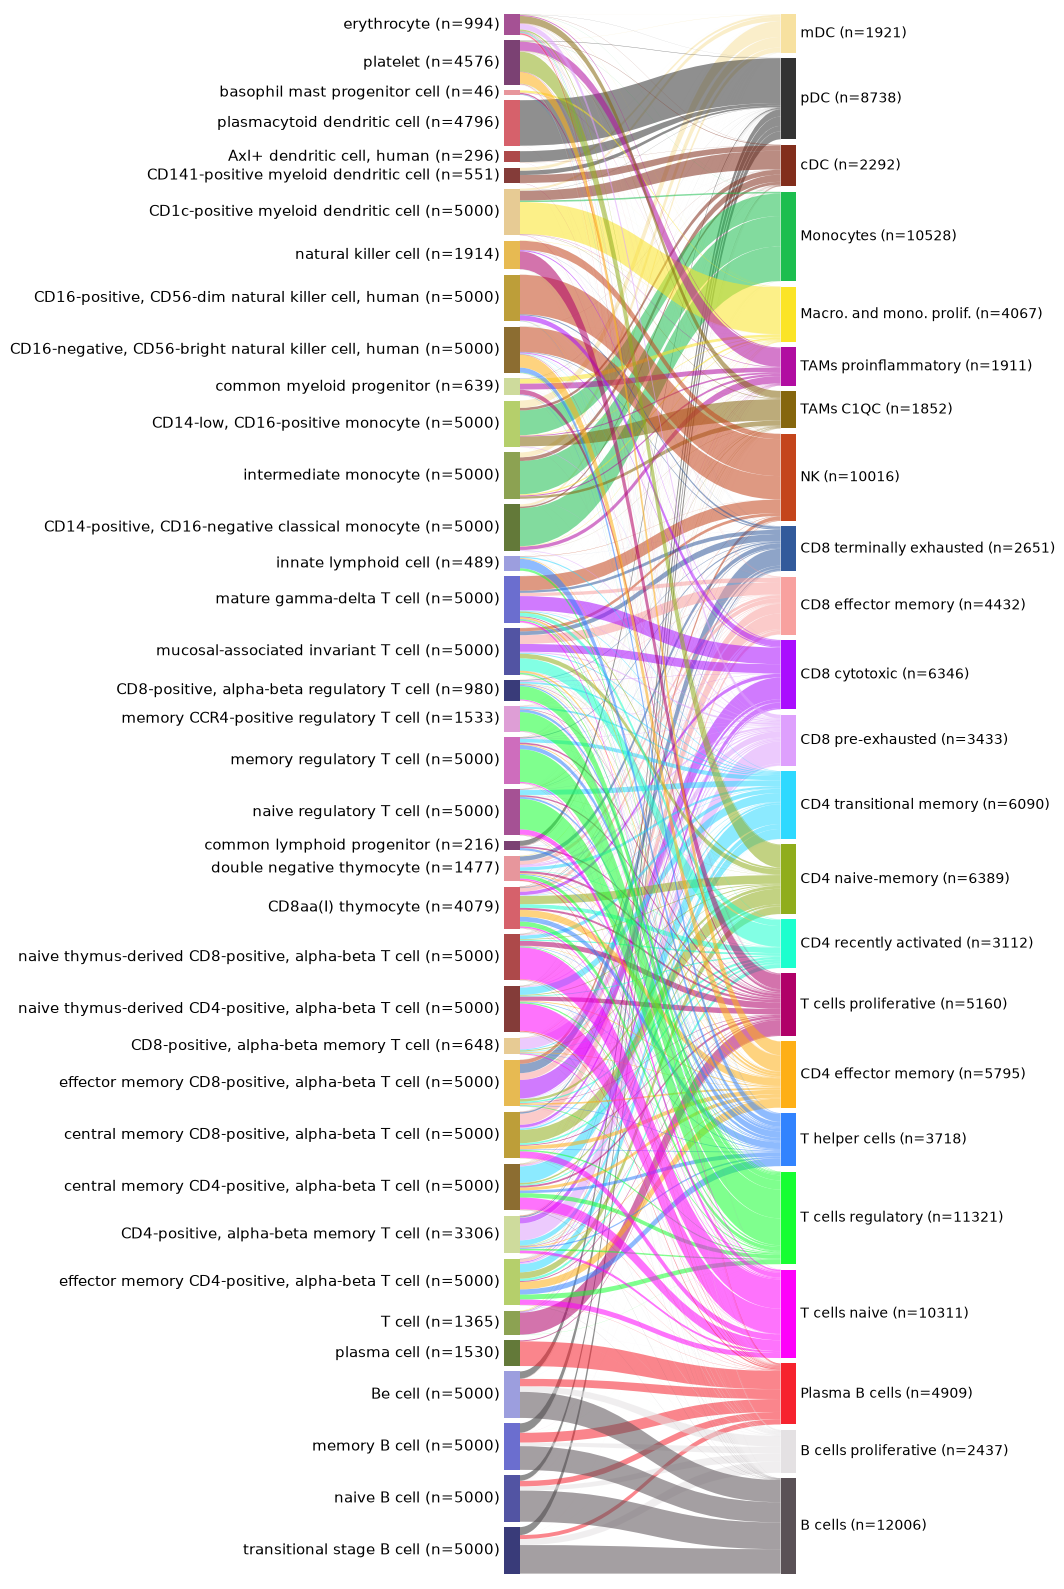

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.path import Path
import numpy as np
import pandas as pd
import os


def riverplot(df, source_col, target_col, source_palette, target_palette,
              source_order=None, target_order=None, figsize=(10, 16),
              transform="sqrt"):
    transform_fns = {
        "linear": lambda x: x,
        "sqrt": np.sqrt,
        "log1p": np.log1p,
    }
    fn = transform_fns[transform]

    flow = df.groupby([source_col, target_col], observed=True).size().reset_index(name="count")
    flow = flow[flow["count"] > 0]

    src_labels = source_order if source_order else list(source_palette.keys())
    tgt_labels = target_order if target_order else list(target_palette.keys())

    src_totals_raw = flow.groupby(source_col, observed=True)["count"].sum().reindex(src_labels).fillna(0)
    tgt_totals_raw = flow.groupby(target_col, observed=True)["count"].sum().reindex(tgt_labels).fillna(0)

    src_totals = src_totals_raw.apply(fn)
    tgt_totals = tgt_totals_raw.apply(fn)

    gap_fraction = 0.15
    n_max = max(len(src_labels), len(tgt_labels))
    gap = (max(src_totals.sum(), tgt_totals.sum()) * gap_fraction) / n_max

    src_height = src_totals.sum() + gap * (len(src_labels) - 1)
    tgt_height = tgt_totals.sum() + gap * (len(tgt_labels) - 1)

    # sqrt(a)+sqrt(b)+... != sqrt(a+b+...) -> die zwei Seiten sind nach der Transformation
    # nicht mehr automatisch gleich hoch. Die kuerzere Seite wird proportional so skaliert,
    # dass ihre reine Balkenhoehe-Summe (ohne gaps) exakt der laengeren Seite entspricht.
    if src_height < tgt_height:
        scale_factor = (tgt_height - gap * (len(src_labels) - 1)) / src_totals.sum()
        src_totals = src_totals * scale_factor
    elif tgt_height < src_height:
        scale_factor = (src_height - gap * (len(tgt_labels) - 1)) / tgt_totals.sum()
        tgt_totals = tgt_totals * scale_factor

    src_height = src_totals.sum() + gap * (len(src_labels) - 1)
    tgt_height = tgt_totals.sum() + gap * (len(tgt_labels) - 1)
    max_height = max(src_height, tgt_height)

    src_offset = (max_height - src_height) / 2
    tgt_offset = (max_height - tgt_height) / 2

    # Fluss-Anteile je Kategorie (Summe pro Kategorie = exakt deren Balkenhoehe)
    flow["src_display"] = flow.apply(
        lambda r: src_totals[r[source_col]] * (r["count"] / src_totals_raw[r[source_col]])
        if src_totals_raw[r[source_col]] > 0 else 0, axis=1
    )
    flow["tgt_display"] = flow.apply(
        lambda r: tgt_totals[r[target_col]] * (r["count"] / tgt_totals_raw[r[target_col]])
        if tgt_totals_raw[r[target_col]] > 0 else 0, axis=1
    )

    src_y_start, y = {}, src_offset
    for lbl in src_labels:
        src_y_start[lbl] = y
        y += src_totals[lbl] + gap

    tgt_y_start, y = {}, tgt_offset
    for lbl in tgt_labels:
        tgt_y_start[lbl] = y
        y += tgt_totals[lbl] + gap

    fig, ax = plt.subplots(figsize=figsize)
    src_cursor = {lbl: src_y_start[lbl] for lbl in src_labels}
    tgt_cursor = {lbl: tgt_y_start[lbl] for lbl in tgt_labels}
    flow_sorted = flow.sort_values(by=[source_col, target_col])

    bar_w = 0.04
    x0, x1, xm = 0.15 + bar_w / 2, 0.85 - bar_w / 2, 0.5

    for _, row in flow_sorted.iterrows():
        s, t = row[source_col], row[target_col]
        c_src, c_tgt = row["src_display"], row["tgt_display"]

        y0_s, y1_s = src_cursor[s], src_cursor[s] + c_src
        y0_t, y1_t = tgt_cursor[t], tgt_cursor[t] + c_tgt
        src_cursor[s], tgt_cursor[t] = y1_s, y1_t

        verts_top = [(x0, y0_s), (xm, y0_s), (xm, y0_t), (x1, y0_t)]
        verts_bot = [(x1, y1_t), (xm, y1_t), (xm, y1_s), (x0, y1_s)]
        path = Path(
            verts_top + verts_bot + [verts_bot[-1]],
            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            + [Path.LINETO] + [Path.CURVE4, Path.CURVE4, Path.CURVE4] + [Path.CLOSEPOLY],
        )
        color = target_palette.get(t, "#CCCCCC")
        ax.add_patch(mpatches.PathPatch(path, facecolor=color, edgecolor="none", alpha=0.55, lw=0))

    for lbl in src_labels:
        color = source_palette.get(lbl, "#CCCCCC")
        ax.add_patch(mpatches.Rectangle((x0 - bar_w, src_y_start[lbl]), bar_w, src_totals[lbl],
                                         facecolor=color, edgecolor="none"))
        ax.text(x0 - bar_w - 0.01, src_y_start[lbl] + src_totals[lbl] / 2,
                f"{lbl} (n={int(src_totals_raw[lbl])})",
                ha="right", va="center", fontsize=11)

    for lbl in tgt_labels:
        color = target_palette.get(lbl, "#CCCCCC")
        ax.add_patch(mpatches.Rectangle((x1, tgt_y_start[lbl]), bar_w, tgt_totals[lbl],
                                         facecolor=color, edgecolor="none"))
        ax.text(x1 + bar_w + 0.01, tgt_y_start[lbl] + tgt_totals[lbl] / 2,
                f"{lbl} (n={int(tgt_totals_raw[lbl])})",
                ha="left", va="center", fontsize=10)

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-gap, max_height + gap)
    ax.axis("off")
    return fig, ax


source_col = "cell_type"
target_col = "decoupler_level1_celltype"

current_cats = set(hiha_ds.obs[target_col].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
hiha_ds.obs[target_col] = hiha_ds.obs[target_col].cat.reorder_categories(list(celltype_palette.keys()))

source_order = list(hiha_ds.obs[source_col].cat.categories) if hasattr(hiha_ds.obs[source_col], "cat") \
    else sorted(hiha_ds.obs[source_col].unique())
n_source = len(source_order)

cmap_name = "tab20" if n_source <= 20 else "tab20b"
cmap = plt.colormaps[cmap_name].resampled(min(n_source, 20))
gbm_source_palette = {ct: mcolors.to_hex(cmap(i % 20)) for i, ct in enumerate(source_order)}

fig, ax = riverplot(hiha_ds.obs, source_col, target_col, gbm_source_palette, celltype_palette,
                     source_order=source_order, target_order=list(celltype_palette.keys()),
                     figsize=(10, 16), transform="sqrt")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_11_2_riverplot_celltype_to_ticalvl1.pdf"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
